# WBTC/WETH Dataset Background Analysis

This notebook is self-contained and no longer imports the local `src/mev_dataset` package. It reads the curated dataset and reproduces the core summary tables and charts. It can load either the original minute-level tables or the newer second-level tables if they exist.


In [1]:
from pathlib import Path
import os

import matplotlib.pyplot as plt
import pandas as pd
import yaml


def find_project_root(start: Path) -> Path:
    current = start.resolve()
    for candidate in [current, *current.parents]:
        if (candidate / 'config/markets.yaml').exists():
            return candidate
        if any(
            path.exists()
            for path in [
                candidate / 'data/curated',
                candidate / 'outputs',
                candidate / 'notebooks',
            ]
        ):
            return candidate
    return current


def load_notebook_settings(project_root: Path) -> dict[str, str]:
    config_path = project_root / 'config/markets.yaml'
    settings = {'curated_data_dir': 'data/curated'}
    if config_path.exists():
        raw = yaml.safe_load(config_path.read_text()) or {}
        settings['curated_data_dir'] = raw.get('curated_data_dir', settings['curated_data_dir'])
    return settings


PROJECT_ROOT = find_project_root(Path.cwd())
os.chdir(PROJECT_ROOT)
settings = load_notebook_settings(PROJECT_ROOT)
curated_dir = PROJECT_ROOT / settings['curated_data_dir']

STATE_TAG = '1s' if (curated_dir / 'pool_state_1s.parquet').exists() else '1m'
pool_state = pd.read_parquet(curated_dir / f'pool_state_{STATE_TAG}.parquet')
arb_labels = pd.read_parquet(curated_dir / f'arb_labels_{STATE_TAG}.parquet')
pool_state['timestamp'] = pd.to_datetime(pool_state['timestamp'], utc=True)
arb_labels['timestamp'] = pd.to_datetime(arb_labels['timestamp'], utc=True)

pd.DataFrame([
    {'dataset': f'pool_state_{STATE_TAG}', 'rows': len(pool_state), 'columns': len(pool_state.columns)},
    {'dataset': f'arb_labels_{STATE_TAG}', 'rows': len(arb_labels), 'columns': len(arb_labels.columns)},
])


,dataset,rows,columns
0,pool_state_1s,5151314,12
1,arb_labels_1s,2562805,15


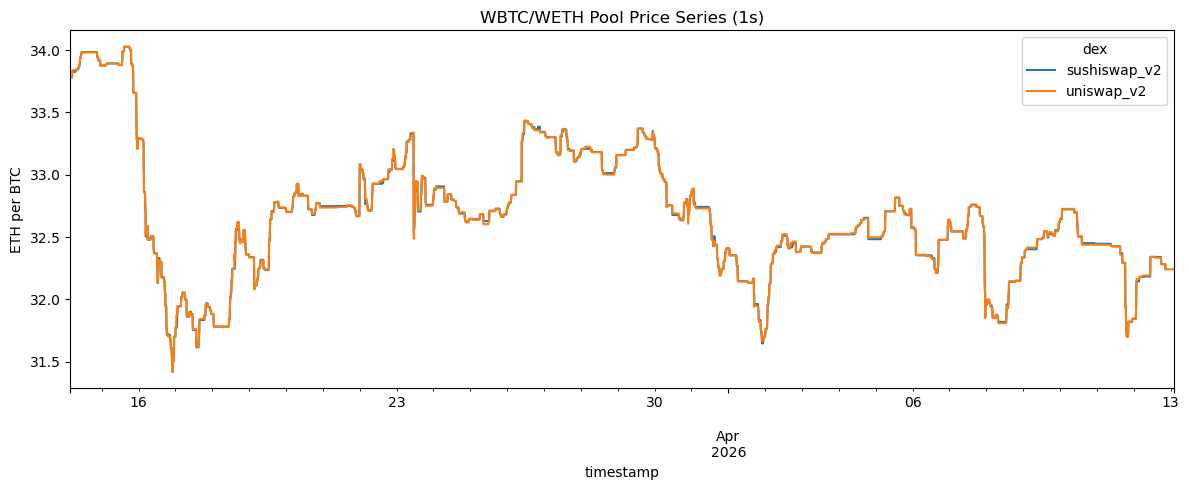

In [2]:
price_pivot = pool_state.pivot(index='timestamp', columns='dex', values='mid_price_eth_per_btc')
plot_price_pivot = price_pivot.resample('5min').last() if STATE_TAG == '1s' else price_pivot
ax = plot_price_pivot.plot(figsize=(12, 5), title=f'WBTC/WETH Pool Price Series ({STATE_TAG})')
ax.set_ylabel('ETH per BTC')
plt.tight_layout()
plt.show()

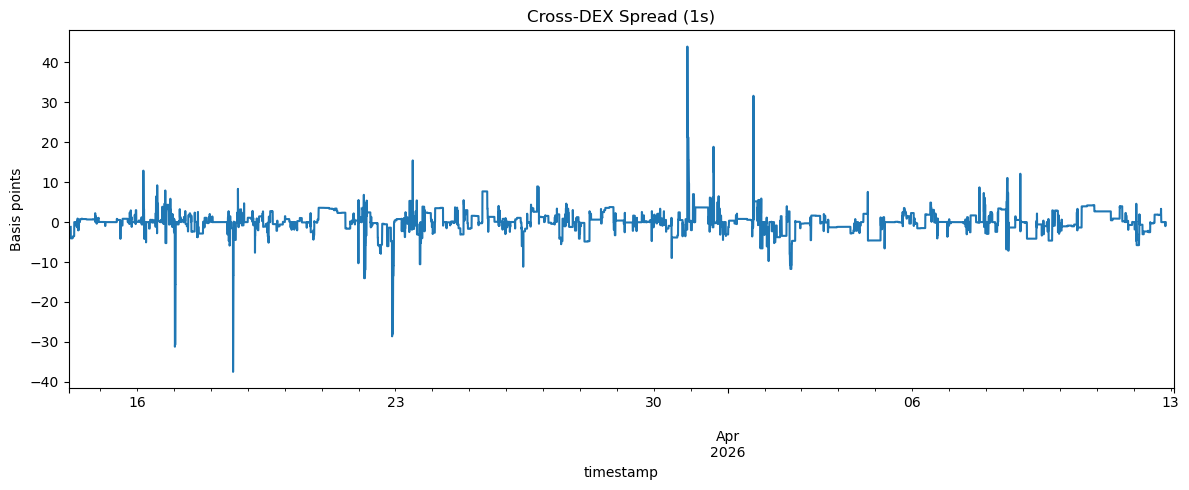

In [3]:
spread_bps = (price_pivot.iloc[:, 0] / price_pivot.iloc[:, 1] - 1.0) * 10_000
plot_spread_bps = spread_bps.resample('5min').last() if STATE_TAG == '1s' else spread_bps
ax = plot_spread_bps.plot(figsize=(12, 5), title=f'Cross-DEX Spread ({STATE_TAG})')
ax.set_ylabel('Basis points')
plt.tight_layout()
plt.show()

In [4]:
swap_activity = (
    pool_state.assign(hour_utc=pool_state['timestamp'].dt.hour)
    .groupby(['dex', 'hour_utc'], as_index=False)
    .agg(
        avg_swap_count=('swap_count', 'mean'),
        avg_volume_wbtc=('volume_wbtc', 'mean'),
        avg_volume_weth=('volume_weth', 'mean'),
    )
)
swap_activity

,dex,hour_utc,avg_swap_count,avg_volume_wbtc,avg_volume_weth
0,sushiswap_v2,0,0.000776,2.115882e-06,0.000069
1,sushiswap_v2,1,0.000738,2.664066e-06,0.000086
2,sushiswap_v2,2,0.000421,1.648565e-06,0.000054
3,sushiswap_v2,3,0.000584,3.014320e-06,0.000098
4,sushiswap_v2,4,0.000563,1.916938e-06,0.000062
5,sushiswap_v2,5,0.000593,1.553099e-06,0.000051
6,sushiswap_v2,6,0.000574,1.585141e-06,0.000052
7,sushiswap_v2,7,0.000463,2.012469e-06,0.000066
8,sushiswap_v2,8,0.000213,8.781563e-07,0.000029
9,sushiswap_v2,9,0.000519,2.043639e-06,0.000067


In [5]:
if 'split' in arb_labels.columns:
    split_descriptives = (
        arb_labels.groupby('split', as_index=False)
        .agg(
            mean_net_edge_bps=('net_edge_bps', 'mean'),
            median_net_edge_bps=('net_edge_bps', 'median'),
            positive_opportunities=('opportunity_flag', 'sum'),
            observations=('timestamp', 'count'),
        )
    )
else:
    split_descriptives = pd.DataFrame(
        [
            {
                'split': 'all',
                'mean_net_edge_bps': float(arb_labels['net_edge_bps'].mean()),
                'median_net_edge_bps': float(arb_labels['net_edge_bps'].median()),
                'positive_opportunities': int(arb_labels['opportunity_flag'].sum()),
                'observations': int(len(arb_labels)),
            }
        ]
    )
split_descriptives


,split,mean_net_edge_bps,median_net_edge_bps,positive_opportunities,observations
0,test,-137.907822,-138.582788,0,384421
1,train,-138.670626,-139.202618,0,1793963
2,validation,-138.697003,-139.153339,0,384421
